[0.2, 0.1] -0.20000000000000004
[0, 0, 0, 1]


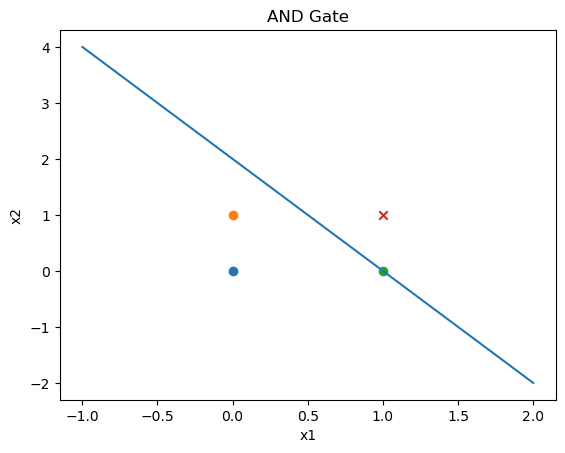

In [10]:
X = [[0,0], [0,1], [1,0], [1,1]]
y = [0, 0, 0, 1]

def step_function(n):
    if n >= 0:
        return 1
    else:
        return 0
def predict(X, weights, bias):
    predictions = []
    for x in X:
        z = 0
        for i in range(len(x)):
            z += weights[i] * x[i]
        z += bias
        predictions.append(step_function(z))
    return predictions

def train_perceptron(X, y, epochs=10, learning_rate=0.1):
    weights = [0, 0]
    bias = 0
    for epoch in range(epochs):
        for i in range(len(X)):
            x = X[i]
            target = y[i]
            z = 0
            for j in range(len(x)):
                z += weights[j] * x[j]
            z += bias
            pred = step_function(z)
            error = target - pred
            for j in range(len(weights)):
                weights[j] += learning_rate * error * x[j]
            bias += learning_rate * error
    return weights, bias
    
import matplotlib.pyplot as plt
def plot_decision_boundary(X, y, weights, bias, title):
    for i in range(len(X)):
        if y[i] == 0:
            plt.scatter(X[i][0], X[i][1], marker='o')
        else:
            plt.scatter(X[i][0], X[i][1], marker='x')
    x1_vals = [-1, 2]
    x2_vals = []
    for x1 in x1_vals:
        if weights[1] != 0:
            x2 = -(weights[0]*x1 + bias) / weights[1]
        else:
            x2 = 0
        x2_vals.append(x2)
    plt.plot(x1_vals, x2_vals)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()
weights, bias = train_perceptron(X, y)
print(weights, bias)
print(predict(X, weights, bias))
plot_decision_boundary(X, y, weights, bias, "AND Gate")

In [14]:
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1
)

loss, accuracy, precision, recall, auc = model.evaluate(X_test, y_test, verbose=0)

print(loss)
print(accuracy)
print(precision)
print(recall)
print(auc)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

<class 'ModuleNotFoundError'>: No module named 'tensorflow'